# Fair Classifier + Baseline Explanations on COMPAS

**Pipeline:**
1. Load & filter `compas-scores-two-years.csv` (ProPublica)
2. Exploratory Data Visualization
3. Preprocess — non-sensitive features only
4. Train MLP classifier
5. Fairness verification (Equalized Odds, Demographic Parity)
6. Baseline SHAP explanations
7. Baseline LIME explanations
8. Confirm sensitive features rank low → save ground truth rankings

## Cell 1 — Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame,
    true_positive_rate,
    false_positive_rate,
    selection_rate
)

import shap
from lime import lime_tabular

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

print('All imports successful.')

All imports successful.


## Cell 2 — Load & Filter Data

In [3]:
URL = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
df_raw = pd.read_csv(URL)
print(f'Raw shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

Raw shape: (7214, 53)
Columns: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


In [4]:
# ── ProPublica standard filters ──────────────────────────────────────────────
df = df_raw.copy()
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']   # exclude ordinary traffic
df = df[df['score_text'] != 'N/A']
df = df[df['race'].isin(['African-American', 'Caucasian'])]  # binary race for fairness eval

df = df.reset_index(drop=True)
print(f'Filtered shape: {df.shape}')
print(f"Race distribution:\n{df['race'].value_counts()}")
print(f"\nTarget distribution:\n{df['two_year_recid'].value_counts()}")

Filtered shape: (5278, 53)
Race distribution:
race
African-American    3175
Caucasian           2103
Name: count, dtype: int64

Target distribution:
two_year_recid
0    2795
1    2483
Name: count, dtype: int64


In [19]:
df.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid', 'charge_degree_F'],
      dtype='object')

## Cell 3 — Exploratory Data Visualization

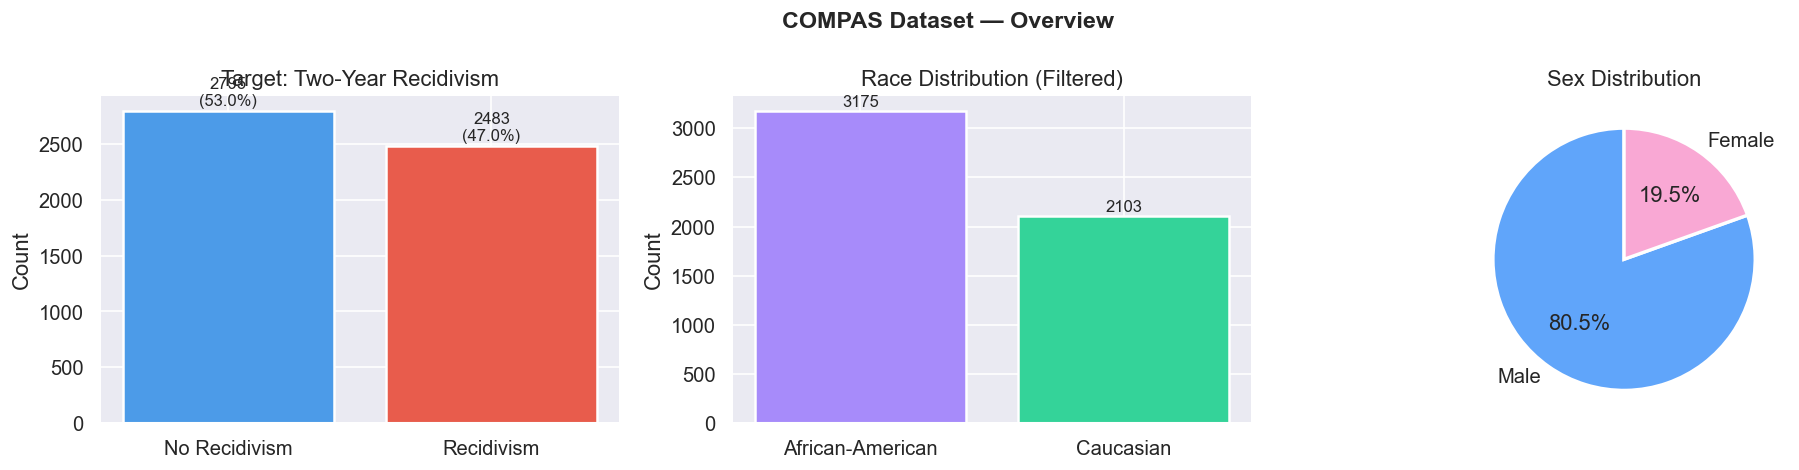

In [5]:
# ── 3.1  Overall class balance ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('COMPAS Dataset — Overview', fontsize=14, fontweight='bold')

# Target distribution
counts = df['two_year_recid'].value_counts()
axes[0].bar(['No Recidivism', 'Recidivism'], counts.values,
            color=['#4C9BE8', '#E85C4C'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target: Two-Year Recidivism')
axes[0].set_ylabel('Count')
for bar, v in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

# Race distribution
race_counts = df['race'].value_counts()
axes[1].bar(race_counts.index, race_counts.values,
            color=['#A78BFA', '#34D399'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Race Distribution (Filtered)')
axes[1].set_ylabel('Count')
for bar, v in zip(axes[1].patches, race_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v}', ha='center', va='bottom', fontsize=10)

# Sex distribution
sex_counts = df['sex'].value_counts()
axes[2].pie(sex_counts.values, labels=sex_counts.index,
            autopct='%1.1f%%', colors=['#60A5FA', '#F9A8D4'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('Sex Distribution')

plt.tight_layout()
plt.savefig('viz_01_overview.png', bbox_inches='tight')
plt.show()

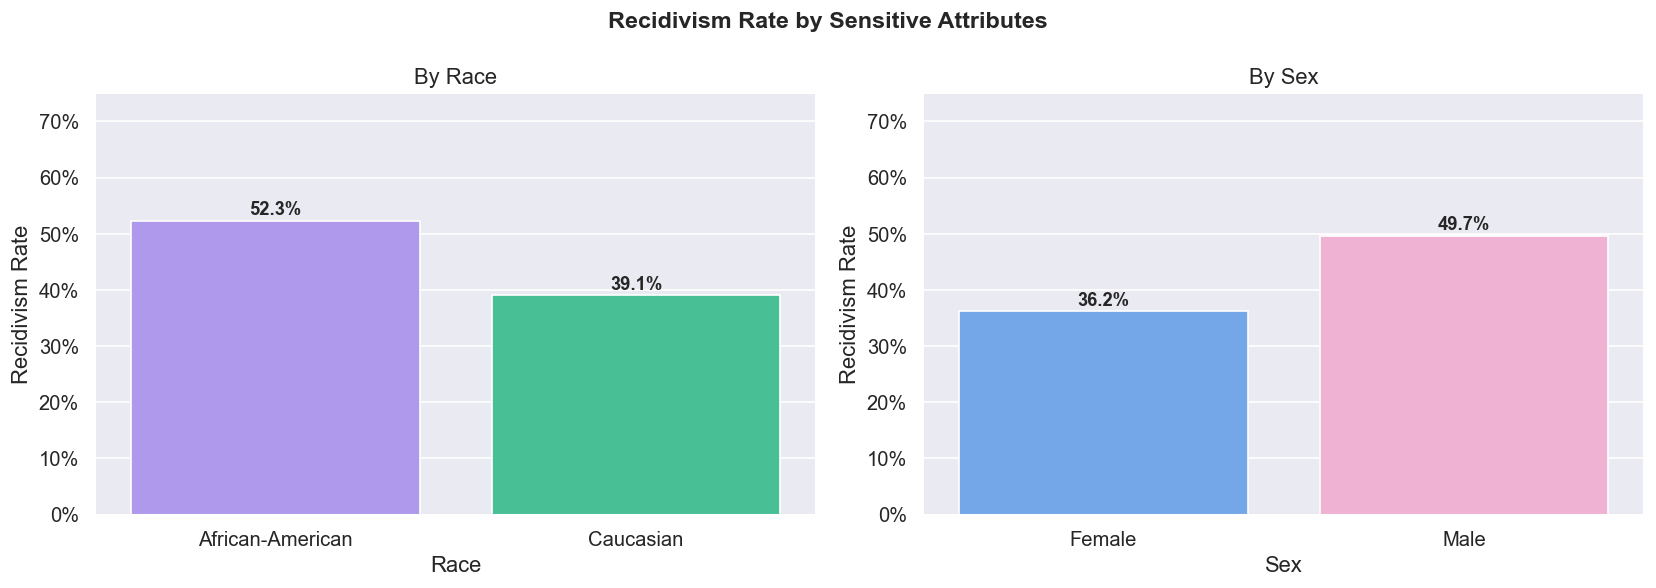

In [6]:
# ── 3.2  Recidivism rate by Race and Sex ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Recidivism Rate by Sensitive Attributes', fontsize=14, fontweight='bold')

# By race
recid_by_race = df.groupby('race')['two_year_recid'].mean().reset_index()
recid_by_race.columns = ['Race', 'Recidivism Rate']
sns.barplot(data=recid_by_race, x='Race', y='Recidivism Rate',
            palette=['#A78BFA', '#34D399'], ax=axes[0], edgecolor='white')
axes[0].set_title('By Race')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_ylim(0, 0.75)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                     ha='center', fontsize=11, fontweight='bold')

# By sex
recid_by_sex = df.groupby('sex')['two_year_recid'].mean().reset_index()
recid_by_sex.columns = ['Sex', 'Recidivism Rate']
sns.barplot(data=recid_by_sex, x='Sex', y='Recidivism Rate',
            palette=['#60A5FA', '#F9A8D4'], ax=axes[1], edgecolor='white')
axes[1].set_title('By Sex')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_ylim(0, 0.75)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                     ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_02_recid_by_sensitive.png', bbox_inches='tight')
plt.show()

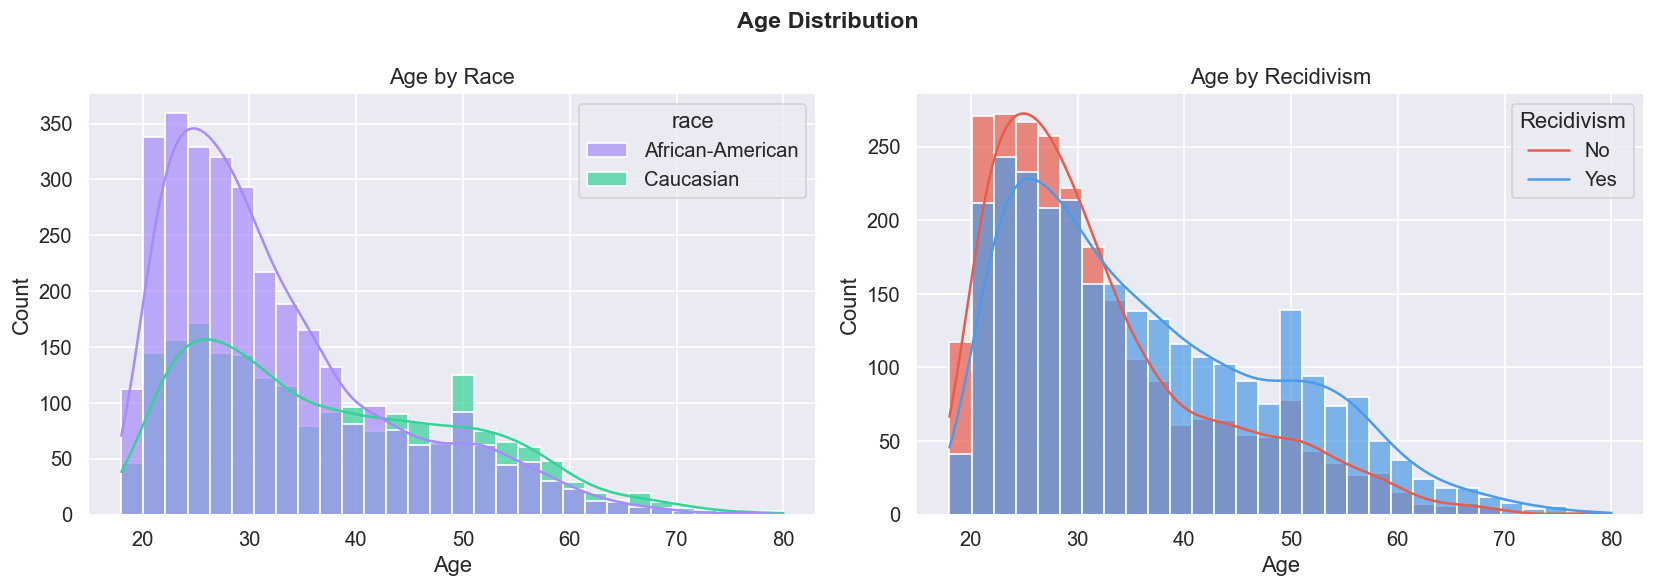

In [7]:
# ── 3.3  Age distribution by Race and Recidivism ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution', fontsize=14, fontweight='bold')

sns.histplot(data=df, x='age', hue='race', bins=30,
             palette=['#A78BFA', '#34D399'], alpha=0.7, ax=axes[0], kde=True)
axes[0].set_title('Age by Race')
axes[0].set_xlabel('Age')

sns.histplot(data=df, x='age', hue='two_year_recid', bins=30,
             palette=['#4C9BE8', '#E85C4C'], alpha=0.7, ax=axes[1], kde=True)
axes[1].set_title('Age by Recidivism')
axes[1].set_xlabel('Age')
axes[1].legend(title='Recidivism', labels=['No', 'Yes'])

plt.tight_layout()
plt.savefig('viz_03_age_dist.png', bbox_inches='tight')
plt.show()

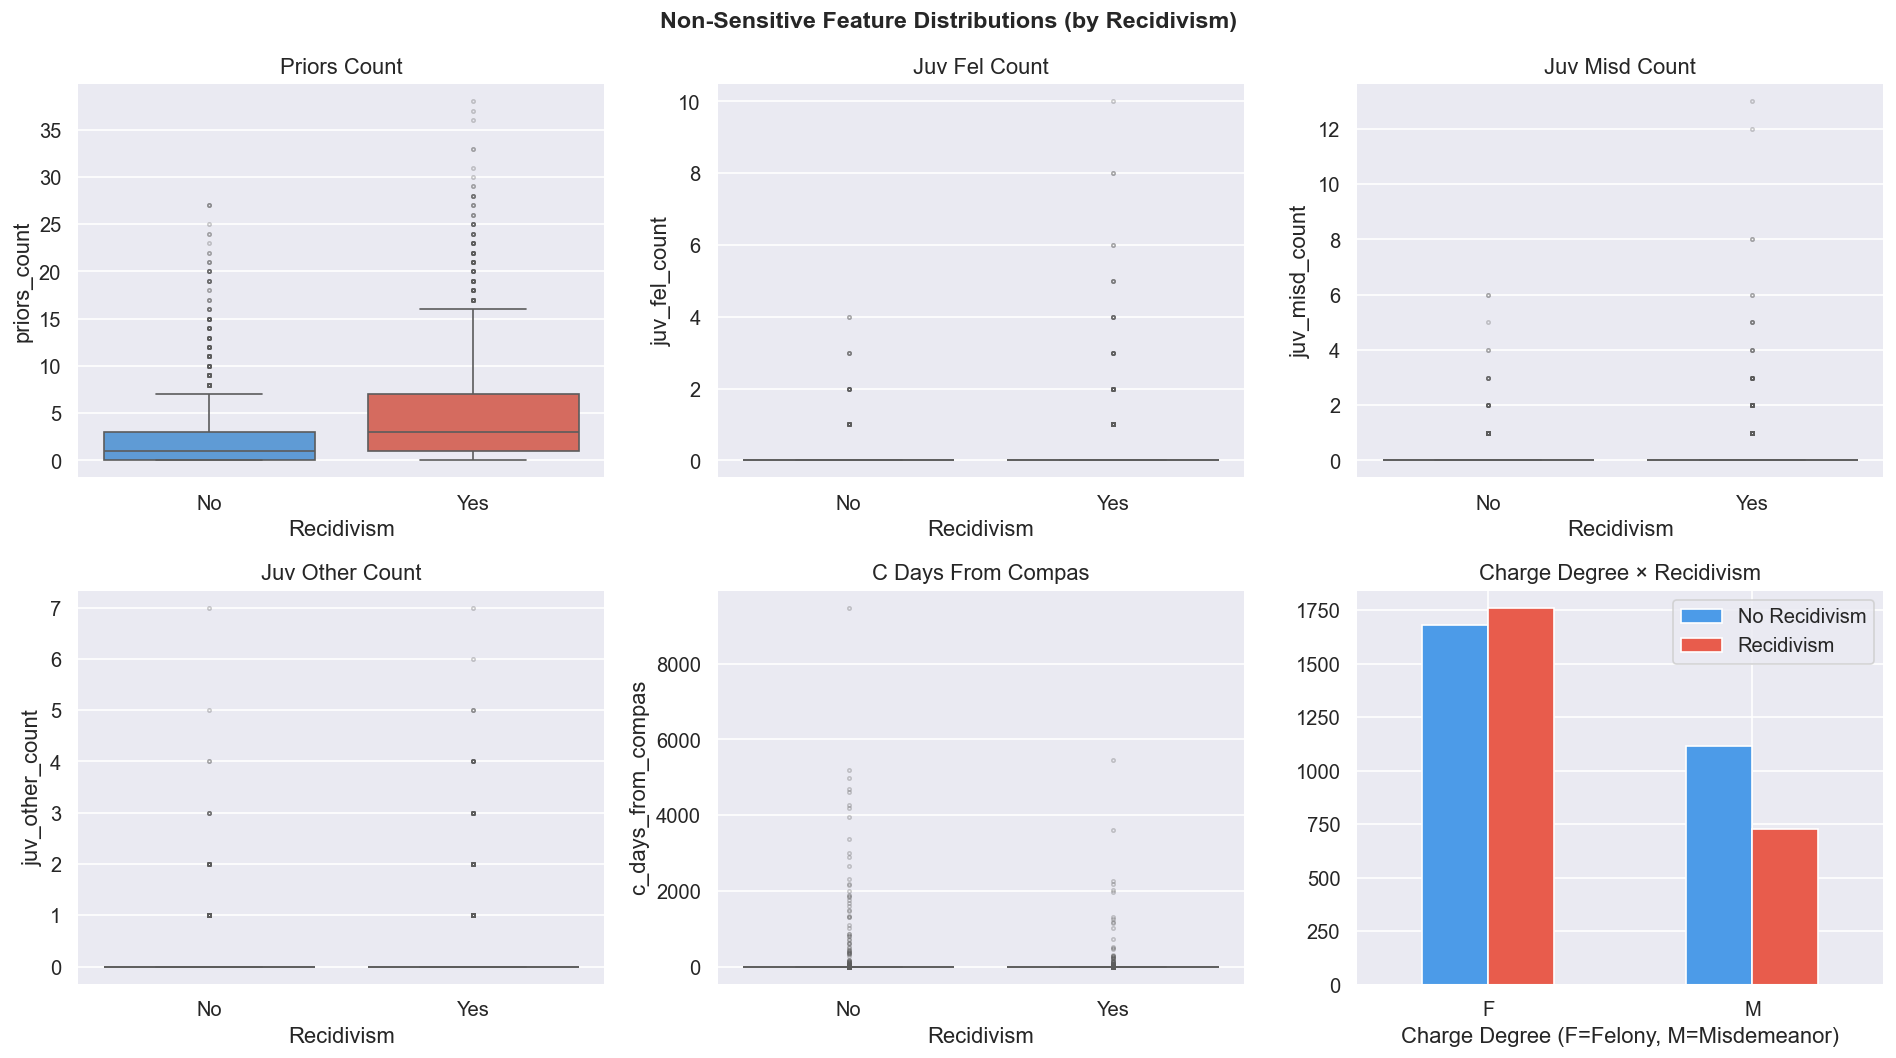

In [8]:
# ── 3.4  Non-sensitive feature distributions ──────────────────────────────────
non_sens_num = ['priors_count', 'juv_fel_count', 'juv_misd_count',
                'juv_other_count', 'c_days_from_compas']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Non-Sensitive Feature Distributions (by Recidivism)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(non_sens_num):
    ax = axes[i]
    sns.boxplot(data=df, x='two_year_recid', y=feat,
                palette=['#4C9BE8', '#E85C4C'], ax=ax,
                showfliers=True, flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Recidivism')
    ax.set_xticklabels(['No', 'Yes'])

# Charge degree breakdown
charge_recid = df.groupby(['c_charge_degree', 'two_year_recid']).size().unstack(fill_value=0)
charge_recid.plot(kind='bar', ax=axes[5], color=['#4C9BE8', '#E85C4C'],
                  edgecolor='white', rot=0)
axes[5].set_title('Charge Degree × Recidivism')
axes[5].set_xlabel('Charge Degree (F=Felony, M=Misdemeanor)')
axes[5].legend(['No Recidivism', 'Recidivism'])

plt.tight_layout()
plt.savefig('viz_04_feature_dists.png', bbox_inches='tight')
plt.show()

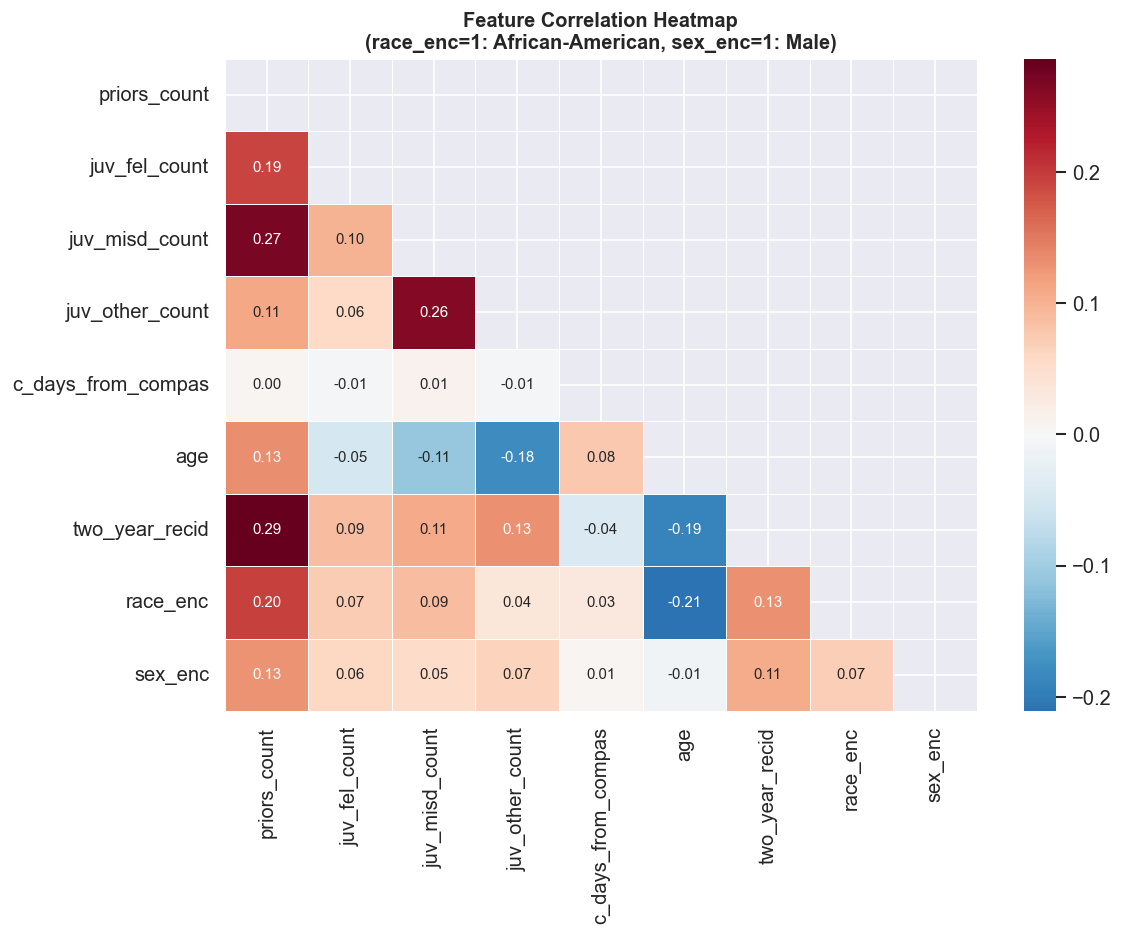


Correlation with target (two_year_recid):
two_year_recid        1.000000
priors_count          0.286675
juv_other_count       0.130025
race_enc              0.129749
juv_misd_count        0.108202
sex_enc               0.107261
juv_fel_count         0.086594
c_days_from_compas   -0.040474
age                  -0.190611


In [9]:
# ── 3.5  Correlation heatmap (all numeric) ────────────────────────────────────
# Encode categoricals temporarily for correlation
df_corr = df[non_sens_num + ['age', 'two_year_recid']].copy()
df_corr['race_enc'] = (df['race'] == 'African-American').astype(int)
df_corr['sex_enc'] = (df['sex'] == 'Male').astype(int)

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap\n(race_enc=1: African-American, sex_enc=1: Male)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_05_correlation.png', bbox_inches='tight')
plt.show()

print("\nCorrelation with target (two_year_recid):")
print(corr['two_year_recid'].sort_values(ascending=False).to_string())

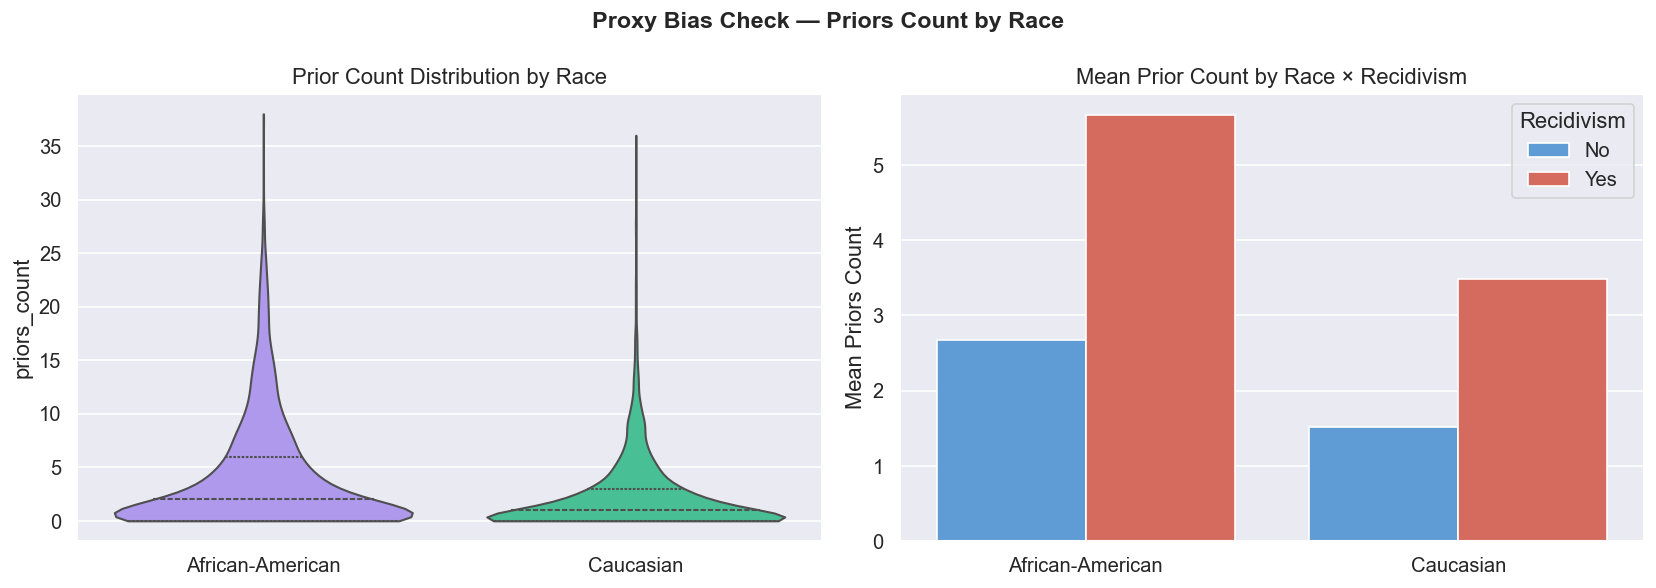

Note: Higher priors_count in African-American group = proxy correlation with race.
This is why even a non-sensitive model won't achieve perfect demographic parity.


In [10]:
# ── 3.6  Prior counts by race — proxy bias check ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Proxy Bias Check — Priors Count by Race', fontsize=14, fontweight='bold')

sns.violinplot(data=df, x='race', y='priors_count',
               palette=['#A78BFA', '#34D399'], ax=axes[0],
               inner='quartile', cut=0)
axes[0].set_title('Prior Count Distribution by Race')
axes[0].set_xlabel('')

# Mean priors by race × recidivism
mean_priors = df.groupby(['race', 'two_year_recid'])['priors_count'].mean().reset_index()
mean_priors['two_year_recid'] = mean_priors['two_year_recid'].map({0: 'No', 1: 'Yes'})
sns.barplot(data=mean_priors, x='race', y='priors_count',
            hue='two_year_recid', palette=['#4C9BE8', '#E85C4C'],
            ax=axes[1], edgecolor='white')
axes[1].set_title('Mean Prior Count by Race × Recidivism')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Priors Count')
axes[1].legend(title='Recidivism')

plt.tight_layout()
plt.savefig('viz_06_proxy_bias.png', bbox_inches='tight')
plt.show()
print("Note: Higher priors_count in African-American group = proxy correlation with race.")
print("This is why even a non-sensitive model won't achieve perfect demographic parity.")

## Cell 4 — Preprocessing (Non-Sensitive Features Only)

In [25]:
# ── Feature sets ─────────────────────────────────────────────────────────────
SENSITIVE_FEATURES = ['race', 'sex', 'age']

# ── Derived features ──────────────────────────────────────────────────────────
df['charge_degree_F'] = (df['c_charge_degree'] == 'F').astype(int)  # 1=Felony, 0=Misdemeanor

# Jail time for current charge (in days)
df['c_jail_in_dt']   = pd.to_datetime(df['c_jail_in'],  errors='coerce')
df['c_jail_out_dt']  = pd.to_datetime(df['c_jail_out'], errors='coerce')
df['jail_time_days'] = (df['c_jail_out_dt'] - df['c_jail_in_dt']).dt.days.fillna(0).clip(lower=0)

TRAIN_FEATURES = [
    # Criminal history
    'priors_count',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    # Current charge
    'charge_degree_F',           # 1=Felony, 0=Misdemeanor
    'c_days_from_compas',        # days between offense and COMPAS screening
    'days_b_screening_arrest',   # days between arrest and COMPAS screening (filtered to ±30)
    'jail_time_days',            # current jail stint length (derived from c_jail_in/out)
]

TARGET = 'two_year_recid'
SENSITIVE_COL = 'race'   # used only for fairness evaluation

X = df[TRAIN_FEATURES].copy()
y = df[TARGET].values
sensitive = df[SENSITIVE_COL].values   # 'African-American' or 'Caucasian'

print(f'Feature matrix: {X.shape}')
print(f'Missing values:\n{X.isnull().sum()}')
print(f'\nFeature dtypes:\n{X.dtypes}')


Feature matrix: (5278, 8)
Missing values:
priors_count               0
juv_fel_count              0
juv_misd_count             0
juv_other_count            0
charge_degree_F            0
c_days_from_compas         0
days_b_screening_arrest    0
jail_time_days             0
dtype: int64

Feature dtypes:
priors_count                 int64
juv_fel_count                int64
juv_misd_count               int64
juv_other_count              int64
charge_degree_F              int64
c_days_from_compas         float64
days_b_screening_arrest    float64
jail_time_days               int64
dtype: object


In [26]:
# ── Train/test split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# ── Scale features ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}')
print(f'Train recidivism rate: {y_train.mean():.3f}')
print(f'Test  recidivism rate: {y_test.mean():.3f}')

Train: (4222, 8)  |  Test: (1056, 8)
Train recidivism rate: 0.470
Test  recidivism rate: 0.471


## Cell 5 — Train MLP Classifier

In [27]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED
)

mlp.fit(X_train_sc, y_train)

y_pred_train = mlp.predict(X_train_sc)
y_pred_test  = mlp.predict(X_test_sc)
y_prob_test  = mlp.predict_proba(X_test_sc)[:, 1]

print(f'Train accuracy: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Test  accuracy: {accuracy_score(y_test,  y_pred_test):.4f}')
print(f'Stopped at iteration: {mlp.n_iter_}')
print()
print('Classification Report (Test):')
print(classification_report(y_test, y_pred_test, target_names=['No Recidivism', 'Recidivism']))

Train accuracy: 0.6644
Test  accuracy: 0.6591
Stopped at iteration: 38

Classification Report (Test):
               precision    recall  f1-score   support

No Recidivism       0.66      0.72      0.69       559
   Recidivism       0.65      0.59      0.62       497

     accuracy                           0.66      1056
    macro avg       0.66      0.66      0.66      1056
 weighted avg       0.66      0.66      0.66      1056



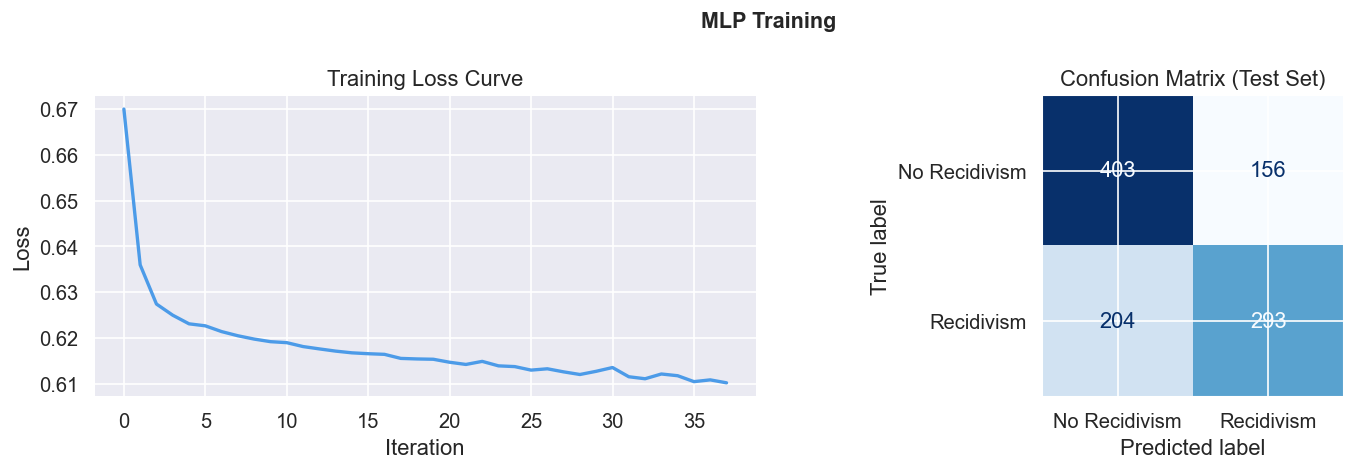

In [28]:
# ── Plot training loss curve ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('MLP Training', fontsize=13, fontweight='bold')

axes[0].plot(mlp.loss_curve_, color='#4C9BE8', linewidth=2)
axes[0].set_title('Training Loss Curve')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')

# Confusion matrix on test set
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Recidivism', 'Recidivism'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Test Set)')

plt.tight_layout()
plt.savefig('viz_07_training.png', bbox_inches='tight')
plt.show()

In [41]:
# ── Fair Model via ThresholdOptimizer ────────────────────────────────────────
from fairlearn.postprocessing import ThresholdOptimizer

fair_clf = ThresholdOptimizer(
    estimator=mlp,                        # your already-trained MLP
    constraints="equalized_odds",         # minimize TPR + FPR gap across groups
    predict_method="predict_proba",
    objective="balanced_accuracy_score"   # preserve accuracy while being fair
)

fair_clf.fit(X_train_sc, y_train, sensitive_features=s_train)

# ── Predictions with the fair model ──────────────────────────────────────────
y_pred_fair = fair_clf.predict(X_test_sc, sensitive_features=s_test)

print(f'Base MLP  accuracy: {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Fair model accuracy: {accuracy_score(y_test, y_pred_fair):.4f}')
print(f'(accuracy/fairness tradeoff is expected)')


Base MLP  accuracy: 0.6591
Fair model accuracy: 0.6402
(accuracy/fairness tradeoff is expected)


## Cell 6 — Fairness Verification

In [42]:
# ── Per-group metrics ─────────────────────────────────────────────────────────
mf = MetricFrame(
    metrics={
        'Accuracy':           accuracy_score,
        'Selection Rate':     selection_rate,
        'TPR (Recall)':       true_positive_rate,
        'FPR':                false_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred_test,
    sensitive_features=s_test
)

print('═' * 55)
print('  Per-Group Metrics (race)')
print('═' * 55)
print(mf.by_group.to_string())

print()
print('═' * 55)
print('  Fairness Summary')
print('═' * 55)

dp_diff = demographic_parity_difference(
    y_test, y_pred_test, sensitive_features=s_test
)
eo_diff = equalized_odds_difference(
    y_test, y_pred_test, sensitive_features=s_test
)

print(f'  Demographic Parity Difference : {dp_diff:+.4f}')
print(f'  Equalized Odds Difference     : {eo_diff:+.4f}')
print()
print('  Thresholds (common in literature):')
print(f'  DP Difference < 0.10  → {"✅ PASS" if abs(dp_diff) < 0.10 else "❌ FAIL"}')
print(f'  EO Difference < 0.10  → {"✅ PASS" if abs(eo_diff) < 0.10 else "❌ FAIL"}')

═══════════════════════════════════════════════════════
  Per-Group Metrics (race)
═══════════════════════════════════════════════════════
                     Accuracy  Selection Rate  TPR (Recall)       FPR
sensitive_feature_0                                                  
African-American     0.658692        0.518341      0.669725  0.353333
Caucasian            0.659674        0.289044      0.435294  0.193050

═══════════════════════════════════════════════════════
  Fairness Summary
═══════════════════════════════════════════════════════
  Demographic Parity Difference : +0.2293
  Equalized Odds Difference     : +0.2344

  Thresholds (common in literature):
  DP Difference < 0.10  → ❌ FAIL
  EO Difference < 0.10  → ❌ FAIL


In [51]:
# ── Compare: base MLP vs fair model ──────────────────────────────────────────
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

dp_base  = demographic_parity_difference(y_test, y_pred_test, sensitive_features=s_test)
eo_base  = equalized_odds_difference(y_test, y_pred_test,  sensitive_features=s_test)

dp_fair  = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=s_test)
eo_fair  = equalized_odds_difference(y_test, y_pred_fair,  sensitive_features=s_test)

print('═' * 55)
print('  Fairness Comparison: Base MLP vs ThresholdOptimizer')
print('═' * 55)
print(f'{"Metric":<35} {"Base MLP":>10} {"Fair Model":>10}')
print('─' * 55)
print(f'{"Demographic Parity Difference":<35} {dp_base:>+10.4f} {dp_fair:>+10.4f}')
print(f'{"Equalized Odds Difference":<35} {eo_base:>+10.4f} {eo_fair:>+10.4f}')
print(f'{"Accuracy":<35} {accuracy_score(y_test, y_pred_test):>10.4f} {accuracy_score(y_test, y_pred_fair):>10.4f}')

# ── Per-group metrics for the fair model ─────────────────────────────────────
mf_fair = MetricFrame(
    metrics={
        'Accuracy':       accuracy_score,
        'Selection Rate': selection_rate,
        'TPR (Recall)':   true_positive_rate,
        'FPR':            false_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred_fair,
    sensitive_features=s_test
)

print('\nPer-Group Metrics (Fair Model):')
print(mf_fair.by_group.to_string())


═══════════════════════════════════════════════════════
  Fairness Comparison: Base MLP vs ThresholdOptimizer
═══════════════════════════════════════════════════════
Metric                                Base MLP Fair Model
───────────────────────────────────────────────────────
Demographic Parity Difference          +0.2293    +0.1007
Equalized Odds Difference              +0.2344    +0.0715
Accuracy                                0.6591     0.6402

Per-Group Metrics (Fair Model):
                     Accuracy  Selection Rate  TPR (Recall)       FPR
sensitive_feature_0                                                  
African-American     0.623604        0.413078      0.535168  0.280000
Caucasian            0.664336        0.312354      0.470588  0.208494


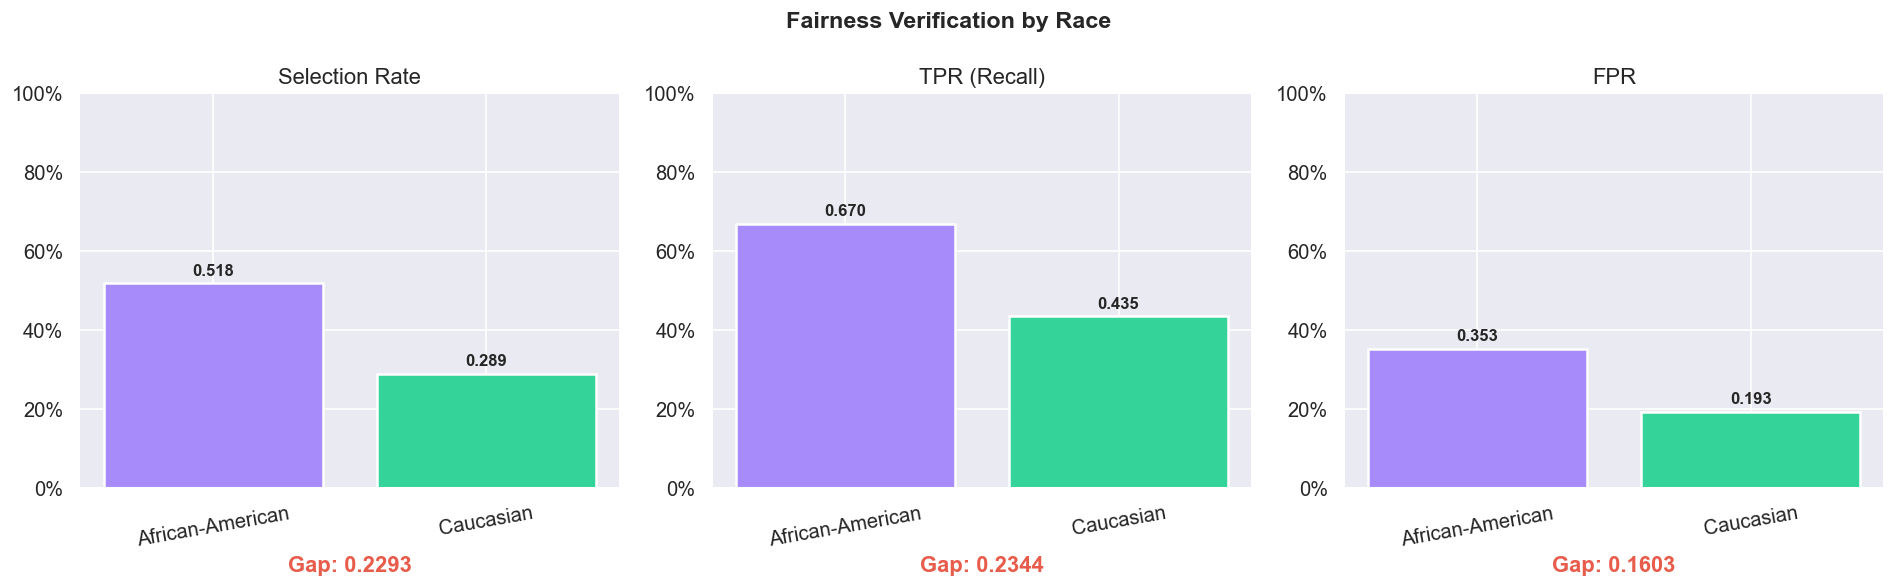


Demographic Parity Difference (DP):  +0.2293
Equalized Odds Difference     (EOD): +0.2344


In [43]:
# ── Fairness visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fairness Verification by Race', fontsize=14, fontweight='bold')

metrics_to_plot = ['Selection Rate', 'TPR (Recall)', 'FPR']
colors = {'African-American': '#A78BFA', 'Caucasian': '#34D399'}

for ax, metric in zip(axes, metrics_to_plot):
    vals = mf.by_group[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=[colors[r] for r in vals.index],
                  edgecolor='white', linewidth=1.5)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xticklabels(vals.index, rotation=10)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02, f'{v:.3f}',
                ha='center', fontsize=10, fontweight='bold')
    # Draw gap annotation
    gap = abs(vals.iloc[0] - vals.iloc[1])
    ax.set_xlabel(f'Gap: {gap:.4f}', color='#E85C4C', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_08_fairness.png', bbox_inches='tight')
plt.show()

print(f"\nDemographic Parity Difference (DP):  {dp_diff:+.4f}")
print(f"Equalized Odds Difference     (EOD): {eo_diff:+.4f}")

In [53]:
# ── Per-group metrics for the FAIR model ─────────────────────────────────────
mf_fair = MetricFrame(
    metrics={
        'Accuracy':       accuracy_score,
        'Selection Rate': selection_rate,
        'TPR (Recall)':   true_positive_rate,
        'FPR':            false_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred_fair,          # ← fair model predictions
    sensitive_features=s_test
)

print('═' * 55)
print('  Per-Group Metrics — Fair Model (race)')
print('═' * 55)
print(mf_fair.by_group.to_string())

# ── Summary numbers ───────────────────────────────────────────────────────────
dp_base = demographic_parity_difference(y_test, y_pred_test, sensitive_features=s_test)
eo_base = equalized_odds_difference(y_test, y_pred_test,  sensitive_features=s_test)
dp_fair = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=s_test)
eo_fair = equalized_odds_difference(y_test, y_pred_fair,  sensitive_features=s_test)

print()
print('═' * 55)
print('  Fairness Summary')
print('═' * 55)
print(f'  {"Metric":<35} {"Base MLP":>8} {"Fair":>8}')
print('  ' + '─' * 51)
print(f'  {"Demographic Parity Difference":<35} {dp_base:>+8.4f} {dp_fair:>+8.4f}')
print(f'  {"Equalized Odds Difference":<35} {eo_base:>+8.4f} {eo_fair:>+8.4f}')
print(f'  {"Accuracy":<35} {accuracy_score(y_test, y_pred_test):>8.4f} {accuracy_score(y_test, y_pred_fair):>8.4f}')
print()
print(f'  DP Difference < 0.10  → {"✅ PASS" if abs(dp_fair) < 0.10 else "❌ FAIL"}')
print(f'  EO Difference < 0.10  → {"✅ PASS" if abs(eo_fair) < 0.10 else "❌ FAIL"}')


═══════════════════════════════════════════════════════
  Per-Group Metrics — Fair Model (race)
═══════════════════════════════════════════════════════
                     Accuracy  Selection Rate  TPR (Recall)       FPR
sensitive_feature_0                                                  
African-American     0.623604        0.413078      0.535168  0.280000
Caucasian            0.664336        0.312354      0.470588  0.208494

═══════════════════════════════════════════════════════
  Fairness Summary
═══════════════════════════════════════════════════════
  Metric                              Base MLP     Fair
  ───────────────────────────────────────────────────
  Demographic Parity Difference        +0.2293  +0.1007
  Equalized Odds Difference            +0.2344  +0.0715
  Accuracy                              0.6591   0.6402

  DP Difference < 0.10  → ❌ FAIL
  EO Difference < 0.10  → ✅ PASS


## Cell 7 — Baseline SHAP Explanations

In [ ]:
# ── SHAP KernelExplainer ──────────────────────────────────────────────────────
print('Computing SHAP background (KMeans k=100)...')
background = shap.kmeans(X_train_sc, 100)

explainer_shap = shap.KernelExplainer(
    mlp.predict_proba,
    background
)

N_EXPLAIN = 200
X_explain_sc = X_test_sc[:N_EXPLAIN]

print(f'Computing SHAP values on {N_EXPLAIN} test samples...')
shap_values = explainer_shap.shap_values(X_explain_sc, nsamples=256, silent=True)

# ── Handle both old and new SHAP API ─────────────────────────────────────────
# Old SHAP (< 0.42): returns list of [class0_array, class1_array]
# New SHAP (≥ 0.42): returns 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]                 # shape: (200, n_features)
else:
    shap_vals_class1 = shap_values[:, :, 1]           # shape: (200, n_features)

print(f'SHAP values shape: {shap_vals_class1.shape}')  # should be (200, 8)

# Global importance: mean |SHAP|
shap_importance = pd.DataFrame({
    'feature': TRAIN_FEATURES,
    'mean_abs_shap': np.abs(shap_vals_class1).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance['rank'] = shap_importance.index + 1
print('\nSHAP Global Feature Importance:')
print(shap_importance.to_string(index=False))


Computing SHAP background (KMeans k=100)...
Computing SHAP values on 200 test samples...
SHAP values shape: (200, 8)

SHAP Global Feature Importance:
                feature  mean_abs_shap  rank
           priors_count       0.102693     1
        charge_degree_F       0.027371     2
        juv_other_count       0.027242     3
days_b_screening_arrest       0.020694     4
         jail_time_days       0.020072     5
         juv_misd_count       0.011807     6
     c_days_from_compas       0.005363     7
          juv_fel_count       0.005197     8


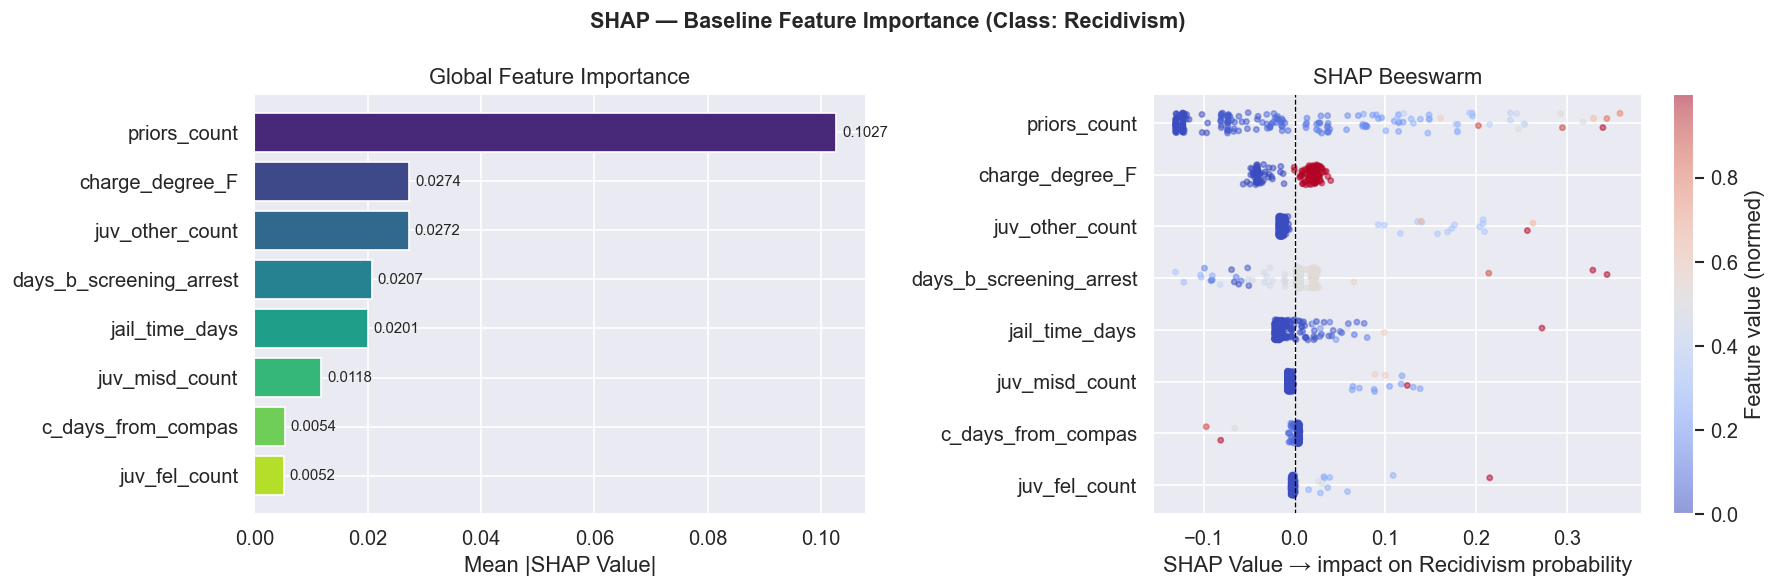

In [45]:
# ── SHAP Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('SHAP — Baseline Feature Importance (Class: Recidivism)', fontsize=13, fontweight='bold')

# Bar plot
colors_shap = sns.color_palette('viridis', len(TRAIN_FEATURES))
ax = axes[0]
bars = ax.barh(shap_importance['feature'][::-1],
               shap_importance['mean_abs_shap'][::-1],
               color=colors_shap[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Global Feature Importance')
for bar, v in zip(bars, shap_importance['mean_abs_shap'][::-1]):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)

# Beeswarm-style scatter (manual)
ax2 = axes[1]
feature_order = shap_importance['feature'].tolist()
for i, feat in enumerate(feature_order[::-1]):
    feat_idx = TRAIN_FEATURES.index(feat)
    sv = shap_vals_class1[:, feat_idx]
    fv_norm = (X_explain_sc[:, feat_idx] - X_explain_sc[:, feat_idx].min()) / \
          (X_explain_sc[:, feat_idx].max() - X_explain_sc[:, feat_idx].min() + 1e-8)

    scatter = ax2.scatter(sv, np.full_like(sv, i) + np.random.uniform(-0.2, 0.2, len(sv)),
                          c=fv_norm, cmap='coolwarm', alpha=0.5, s=10)
ax2.set_yticks(range(len(feature_order)))
ax2.set_yticklabels(feature_order[::-1])
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('SHAP Value → impact on Recidivism probability')
ax2.set_title('SHAP Beeswarm')
plt.colorbar(scatter, ax=ax2, label='Feature value (normed)')

plt.tight_layout()
plt.savefig('viz_09_shap.png', bbox_inches='tight')
plt.show()

## Cell 8 — Baseline LIME Explanations

In [46]:
# ── LIME TabularExplainer ─────────────────────────────────────────────────────
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_sc,
    feature_names=TRAIN_FEATURES,
    class_names=['No Recidivism', 'Recidivism'],
    mode='classification',
    discretize_continuous=True,
    random_state=SEED
)

# Aggregate LIME importances over N_EXPLAIN test samples
print(f'Computing LIME explanations for {N_EXPLAIN} samples...')
lime_importance_agg = {feat: 0.0 for feat in TRAIN_FEATURES}

for i in range(N_EXPLAIN):
    exp = lime_explainer.explain_instance(
        X_explain_sc[i],
        mlp.predict_proba,
        num_features=len(TRAIN_FEATURES),
        num_samples=1000,
        labels=(1,)
    )
    for feat_str, weight in exp.as_list(label=1):
        # LIME feature strings are like 'priors_count > 2.5'
        for feat in TRAIN_FEATURES:
            if feat in feat_str:
                lime_importance_agg[feat] += abs(weight)
                break
    if (i + 1) % 50 == 0:
        print(f'  [{i+1}/{N_EXPLAIN}] done')

lime_importance = pd.DataFrame({
    'feature': list(lime_importance_agg.keys()),
    'mean_abs_lime': [v / N_EXPLAIN for v in lime_importance_agg.values()]
}).sort_values('mean_abs_lime', ascending=False).reset_index(drop=True)

lime_importance['rank'] = lime_importance.index + 1
print('\nLIME Global Feature Importance (aggregated):')
print(lime_importance.to_string(index=False))

Computing LIME explanations for 200 samples...
  [50/200] done
  [100/200] done
  [150/200] done
  [200/200] done

LIME Global Feature Importance (aggregated):
                feature  mean_abs_lime  rank
        juv_other_count       0.155144     1
days_b_screening_arrest       0.129748     2
     c_days_from_compas       0.127285     3
         juv_misd_count       0.114601     4
          juv_fel_count       0.095546     5
           priors_count       0.082698     6
         jail_time_days       0.026128     7
        charge_degree_F       0.024500     8


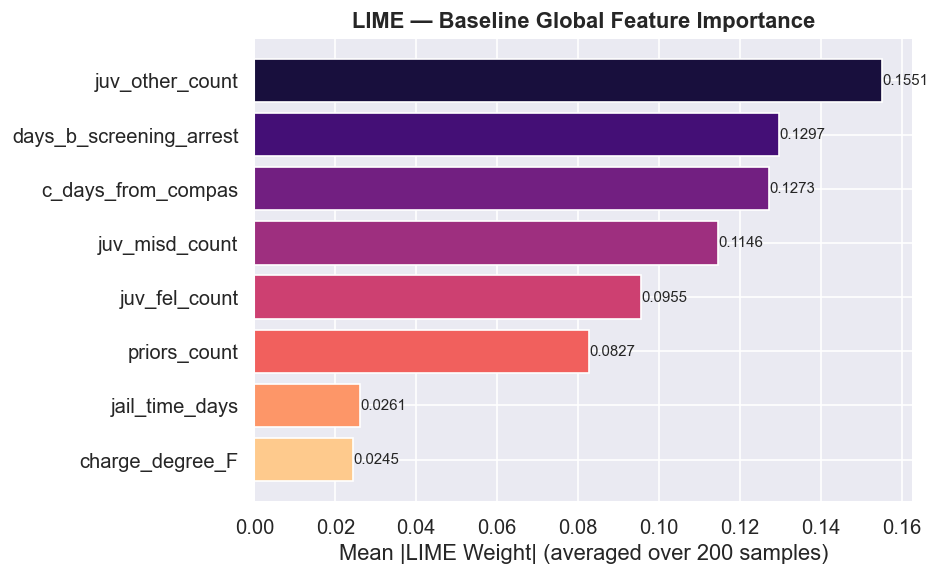

In [47]:
# ── LIME bar plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors_lime = sns.color_palette('magma', len(TRAIN_FEATURES))

bars = ax.barh(lime_importance['feature'][::-1],
               lime_importance['mean_abs_lime'][::-1],
               color=colors_lime[::-1], edgecolor='white')
ax.set_xlabel('Mean |LIME Weight| (averaged over 200 samples)')
ax.set_title('LIME — Baseline Global Feature Importance', fontweight='bold')
for bar, v in zip(bars, lime_importance['mean_abs_lime'][::-1]):
    ax.text(v + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_10_lime.png', bbox_inches='tight')
plt.show()

## Cell 9 — Ground Truth: Confirm Sensitive Features Rank Low

In [48]:
# ── Re-run SHAP with sensitive features as PASSIVE observers ─────────────────
# (they are NOT used in training, but we add them to the explanation input
#  to measure what rank they would hypothetically receive)

ALL_FEATURES = TRAIN_FEATURES + ['race_enc', 'sex_enc', 'age']

df_aug = df[TRAIN_FEATURES].copy()
df_aug['race_enc'] = (df['race'] == 'African-American').astype(int).values
df_aug['sex_enc']  = (df['sex'] == 'Male').astype(int).values
df_aug['age']      = df['age'].values

X_aug = df_aug.values
X_aug_train, X_aug_test = X_aug[X_train.index], X_aug[X_test.index]

scaler_aug = StandardScaler()
X_aug_train_sc = scaler_aug.fit_transform(X_aug_train)
X_aug_test_sc  = scaler_aug.transform(X_aug_test)

# A wrapper that feeds only the first 6 features to the MLP
def mlp_predict_aug(X_aug_input):
    return mlp.predict_proba(X_aug_input[:, :len(TRAIN_FEATURES)])

print('Computing augmented SHAP (with sensitive features as observers)...')
bg_aug = shap.kmeans(X_aug_train_sc, 100)
exp_aug = shap.KernelExplainer(mlp_predict_aug, bg_aug)
shap_aug = exp_aug.shap_values(X_aug_test_sc[:N_EXPLAIN], nsamples=256, silent=True)

# Version-safe extraction
if isinstance(shap_aug, list):
    shap_aug_class1 = shap_aug[1]
else:
    shap_aug_class1 = shap_aug[:, :, 1]


shap_aug_importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'mean_abs_shap': np.abs(shap_aug_class1).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_aug_importance['rank'] = shap_aug_importance.index + 1

print('\nSHAP Rankings (ALL features — sensitive shown as passive observers):')
print(shap_aug_importance.to_string(index=False))

Computing augmented SHAP (with sensitive features as observers)...

SHAP Rankings (ALL features — sensitive shown as passive observers):
                feature  mean_abs_shap  rank
           priors_count       0.106096     1
        charge_degree_F       0.028219     2
        juv_other_count       0.026952     3
         jail_time_days       0.022317     4
days_b_screening_arrest       0.019870     5
         juv_misd_count       0.010347     6
     c_days_from_compas       0.005513     7
          juv_fel_count       0.005030     8
                    age       0.000113     9
                sex_enc       0.000111    10
               race_enc       0.000100    11


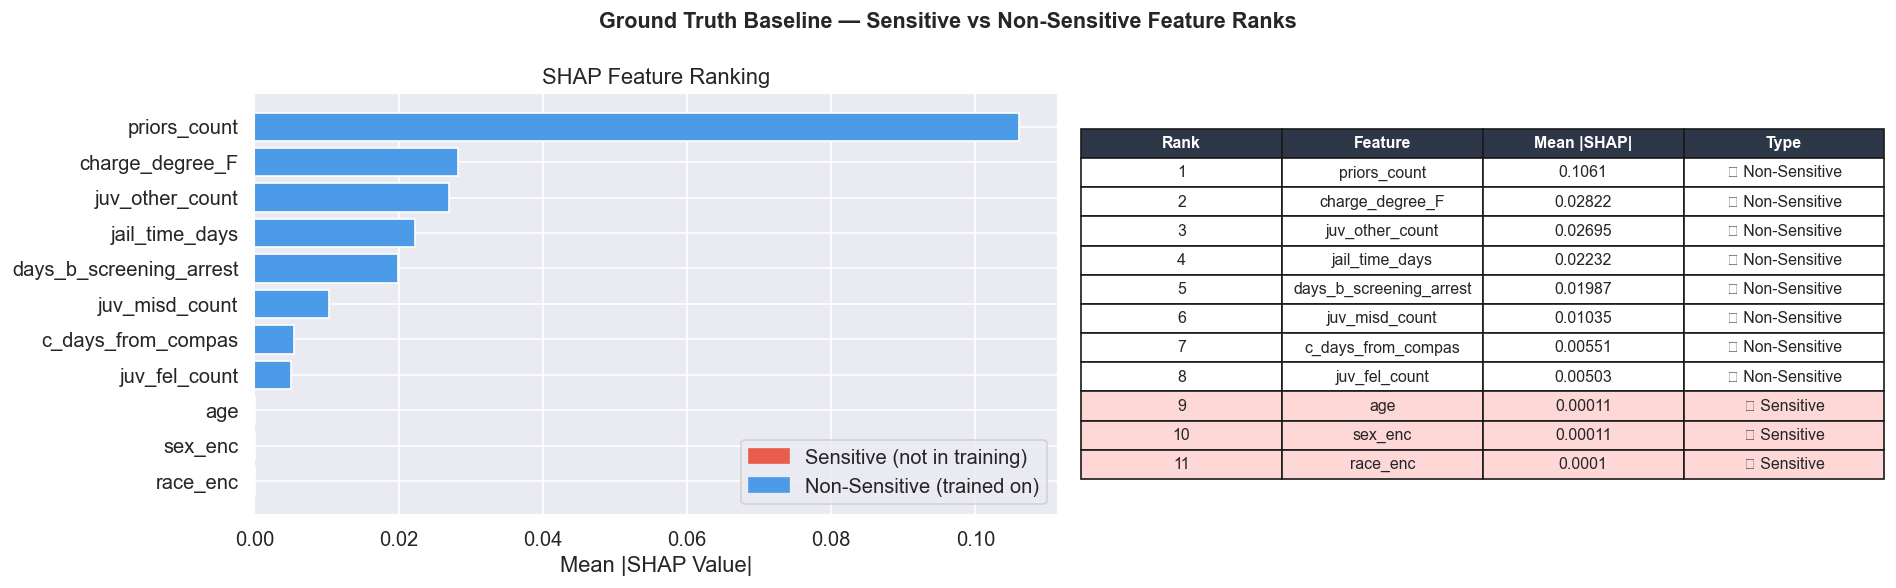

In [49]:
# ── Ground truth summary visualization ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Ground Truth Baseline — Sensitive vs Non-Sensitive Feature Ranks', fontsize=13, fontweight='bold')

sensitive_feats = {'race_enc', 'sex_enc', 'age'}

palette = [
    '#E85C4C' if f in sensitive_feats else '#4C9BE8'
    for f in shap_aug_importance['feature'][::-1]
]

# SHAP rankings
axes[0].barh(shap_aug_importance['feature'][::-1],
             shap_aug_importance['mean_abs_shap'][::-1],
             color=palette, edgecolor='white')
axes[0].set_xlabel('Mean |SHAP Value|')
axes[0].set_title('SHAP Feature Ranking')

from matplotlib.patches import Patch
legend_els = [Patch(color='#E85C4C', label='Sensitive (not in training)'),
              Patch(color='#4C9BE8', label='Non-Sensitive (trained on)')]
axes[0].legend(handles=legend_els, loc='lower right')

# Rank table
table_data = shap_aug_importance[['rank', 'feature', 'mean_abs_shap']].copy()
table_data['mean_abs_shap'] = table_data['mean_abs_shap'].round(5)
table_data['type'] = table_data['feature'].apply(
    lambda f: '🔴 Sensitive' if f in sensitive_feats else '🔵 Non-Sensitive'
)

axes[1].axis('off')
tbl = axes[1].table(
    cellText=table_data.values,
    colLabels=['Rank', 'Feature', 'Mean |SHAP|', 'Type'],
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2D3748')
        cell.set_text_props(color='white', fontweight='bold')
    elif table_data.iloc[r-1]['feature'] in sensitive_feats if r > 0 else False:
        cell.set_facecolor('#FED7D7')

plt.tight_layout()
plt.savefig('viz_11_ground_truth.png', bbox_inches='tight')
plt.show()

In [54]:
# ── Save rankings to CSV (ground truth for attack experiments) ────────────────
shap_importance.to_csv('baseline_shap_rankings.csv', index=False)
lime_importance.to_csv('baseline_lime_rankings.csv', index=False)
shap_aug_importance.to_csv('baseline_shap_all_features_rankings.csv', index=False)

print('Saved:')
print('  baseline_shap_rankings.csv              — SHAP (non-sensitive features only)')
print('  baseline_lime_rankings.csv              — LIME (non-sensitive features only)')
print('  baseline_shap_all_features_rankings.csv — SHAP (incl. sensitive as observers)')

# ── Final Ground Truth Summary ────────────────────────────────────────────────
print()
print('═' * 65)
print('  GROUND TRUTH VERIFICATION')
print('═' * 65)

sens_ranks     = shap_aug_importance[shap_aug_importance['feature'].isin(sensitive_feats)]
non_sens_ranks = shap_aug_importance[~shap_aug_importance['feature'].isin(sensitive_feats)]

print(f'  Sensitive feature ranks   : {sorted(sens_ranks["rank"].tolist())}')
print(f'  Non-sensitive avg rank    : {non_sens_ranks["rank"].mean():.2f}')
print(f'  Sensitive avg rank        : {sens_ranks["rank"].mean():.2f}')

all_sens_low = all(r > len(TRAIN_FEATURES) // 2 for r in sens_ranks['rank'])
print()
print(f'  Sensitive features rank in bottom half : {"✅ CONFIRMED" if all_sens_low else "⚠️  CHECK MANUALLY"}')
print()
print(f'  [Fair Model — ThresholdOptimizer]')                      # ← changed
print(f'  Demographic Parity Difference : {dp_fair:>+.4f}  '       # ← dp_fair
      f'({"✅ PASS" if abs(dp_fair) < 0.10 else "❌ FAIL"})')
print(f'  Equalized Odds Difference     : {eo_fair:>+.4f}  '       # ← eo_fair
      f'({"✅ PASS" if abs(eo_fair) < 0.10 else "❌ FAIL"})')
print()
print(f'  [Base MLP — for reference]')
print(f'  Demographic Parity Difference : {dp_base:>+.4f}')
print(f'  Equalized Odds Difference     : {eo_base:>+.4f}')
print('═' * 65)
print()
print('Note: SHAP/LIME rankings explain the BASE MLP.')
print('      Fairness is achieved via ThresholdOptimizer (post-processing).')
print('      This is the attack surface: base model is biased,')
print('      explanations describe base model behavior.')
print()
print('Baseline pipeline complete. Rankings saved → ready for attack experiments.')


Saved:
  baseline_shap_rankings.csv              — SHAP (non-sensitive features only)
  baseline_lime_rankings.csv              — LIME (non-sensitive features only)
  baseline_shap_all_features_rankings.csv — SHAP (incl. sensitive as observers)

═════════════════════════════════════════════════════════════════
  GROUND TRUTH VERIFICATION
═════════════════════════════════════════════════════════════════
  Sensitive feature ranks   : [9, 10, 11]
  Non-sensitive avg rank    : 4.50
  Sensitive avg rank        : 10.00

  Sensitive features rank in bottom half : ✅ CONFIRMED

  [Fair Model — ThresholdOptimizer]
  Demographic Parity Difference : +0.1007  (❌ FAIL)
  Equalized Odds Difference     : +0.0715  (✅ PASS)

  [Base MLP — for reference]
  Demographic Parity Difference : +0.2293
  Equalized Odds Difference     : +0.2344
═════════════════════════════════════════════════════════════════

Note: SHAP/LIME rankings explain the BASE MLP.
      Fairness is achieved via ThresholdOptimizer (post-